# -------------------------------- PROJET DATA SCIENCE --------------------------------

## 1- BUSINESS UNDERSTANDING (DEFINIR LE PROJET)

- Prédiction des prix des voiturs par les différentes variables qui le lient.
- La régression linéaire pour prédire les prix en en fonction des variables indépendantes.
- La variable à expliquer ou dépendante ou en encore la variable cible est le `prix`

## 2- CHARGEMENT DES DONNÉES

In [1]:
# LES LIBRAIRIES

# 1. DATA MANUPULATION
import pandas as pd
import numpy as np

# 2. DATA VISUALISATION
import matplotlib.pyplot as plt
import seaborn as sns

# 3. LES TESTES STATISTIQUES
from scipy.stats import ttest_ind, pearsonr, chi2_contingency, f_oneway

# 4. MACHINE LEARNING (ML)
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
print("=="*20)
print("APPERÇU DES DONNÉES")
print("=="*20)

APPERÇU DES DONNÉES


In [3]:
# LECTURE DES DONNÉES
df = pd.read_csv("use_of_cars.csv")
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

df # Lire le du dataset

,Unnamed: 0,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,0.890278,48.8,2548,dohc,four,130,mpfi,3.470000,2.68,9.00,111.000000,5000.000000,21,27,13495.0,11.190476,Medium,0,1
1,1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,0.890278,48.8,2548,dohc,four,130,mpfi,3.470000,2.68,9.00,111.000000,5000.000000,21,27,16500.0,11.190476,Medium,0,1
2,2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,0.909722,52.4,2823,ohcv,six,152,mpfi,2.680000,3.47,9.00,154.000000,5000.000000,19,26,16500.0,12.368421,Medium,0,1
3,3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,0.919444,54.3,2337,ohc,four,109,mpfi,3.190000,3.40,10.00,102.000000,5500.000000,24,30,13950.0,9.791667,Medium,0,1
4,4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,0.922222,54.3,2824,ohc,five,136,mpfi,3.190000,3.40,8.00,115.000000,5500.000000,18,22,17450.0,13.055556,Medium,0,1
5,5,2,122,audi,std,two,sedan,fwd,front,99.8,0.851994,0.920833,53.1,2507,ohc,five,136,mpfi,3.190000,3.40,8.50,110.000000,5500.000000,19,25,15250.0,12.368421,Medium,0,1
6,6,1,158,audi,std,four,sedan,fwd,front,105.8,0.925997,0.991667,55.7,2844,ohc,five,136,mpfi,3.190000,3.40,8.50,110.000000,5500.000000,19,25,17710.0,12.368421,Medium,0,1
7,7,1,122,audi,std,four,wagon,fwd,front,105.8,0.925997,0.991667,55.7,2954,ohc,five,136,mpfi,3.190000,3.40,8.50,110.000000,5500.000000,19,25,18920.0,12.368421,Medium,0,1
8,8,1,158,audi,turbo,four,sedan,fwd,front,105.8,0.925997,0.991667,55.9,3086,ohc,five,131,mpfi,3.130000,3.40,8.30,140.000000,5500.000000,17,20,23875.0,13.823529,Medium,0,1
9,9,2,192,bmw,std,two,sedan,rwd,front,101.2,0.849592,0.900000,54.3,2395,ohc,four,108,mpfi,3.500000,2.80,8.80,101.000000,5800.000000,23,29,16430.0,10.217391,Low,0,1


In [4]:
# Les informations concernant le DATASET
print("LES INFORAMTIONS DATA")
df.info()

LES INFORAMTIONS DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         201 non-null    int64  
 1   symboling          201 non-null    int64  
 2   normalized-losses  201 non-null    int64  
 3   make               201 non-null    object 
 4   aspiration         201 non-null    object 
 5   num-of-doors       201 non-null    object 
 6   body-style         201 non-null    object 
 7   drive-wheels       201 non-null    object 
 8   engine-location    201 non-null    object 
 9   wheel-base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb-weight        201 non-null    int64  
 14  engine-type        201 non-null    object 
 15  num-of-cylinders   201 non-null    object 
 16  engi

In [5]:
# L'ANALYSE DESCRIPTIVE DU DATASET
df.describe(include="all")

,Unnamed: 0,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
count,201.000000,201.000000,201.00000,201,201,201,201,201,201,201.000000,201.000000,201.000000,201.000000,201.000000,201,201,201.000000,201,201.000000,197.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,200,201.000000,201.000000
unique,NaN,NaN,NaN,22,2,2,5,3,2,NaN,NaN,NaN,NaN,NaN,6,7,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN
top,NaN,NaN,NaN,toyota,std,four,sedan,fwd,front,NaN,NaN,NaN,NaN,NaN,ohc,four,NaN,mpfi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN
freq,NaN,NaN,NaN,32,165,115,94,118,198,NaN,NaN,NaN,NaN,NaN,145,157,NaN,92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115,NaN,NaN
mean,100.000000,0.840796,122.00000,NaN,NaN,NaN,NaN,NaN,NaN,98.797015,0.837102,0.915126,53.766667,2555.666667,NaN,NaN,126.875622,NaN,3.330692,3.256904,10.164279,103.405534,5117.665368,25.179104,30.686567,13207.129353,9.944145,NaN,0.099502,0.900498
std,58.167861,1.254802,31.99625,NaN,NaN,NaN,NaN,NaN,NaN,6.066366,0.059213,0.029187,2.447822,517.296727,NaN,NaN,41.546834,NaN,0.268072,0.319256,4.004965,37.365700,478.113805,6.423220,6.815150,7947.066342,2.534599,NaN,0.300083,0.300083
min,0.000000,-2.000000,65.00000,NaN,NaN,NaN,NaN,NaN,NaN,86.600000,0.678039,0.837500,47.800000,1488.000000,NaN,NaN,61.000000,NaN,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000,4.795918,NaN,0.000000,0.000000
25%,50.000000,0.000000,101.00000,NaN,NaN,NaN,NaN,NaN,NaN,94.500000,0.801538,0.890278,52.000000,2169.000000,NaN,NaN,98.000000,NaN,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000,7.833333,NaN,0.000000,1.000000
50%,100.000000,1.000000,122.00000,NaN,NaN,NaN,NaN,NaN,NaN,97.000000,0.832292,0.909722,54.100000,2414.000000,NaN,NaN,120.000000,NaN,3.310000,3.290000,9.000000,95.000000,5125.369458,24.000000,30.000000,10295.000000,9.791667,NaN,0.000000,1.000000
75%,150.000000,2.000000,137.00000,NaN,NaN,NaN,NaN,NaN,NaN,102.400000,0.881788,0.925000,55.500000,2926.000000,NaN,NaN,141.000000,NaN,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000,12.368421,NaN,0.000000,1.000000


In [6]:
# LES STATTISTIQUES DES VALEURS CATÉGORIELLES
df.describe(include="object")

,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system,horsepower-binned
count,201,201,201,201,201,201,201,201,201,200
unique,22,2,2,5,3,2,6,7,8,3
top,toyota,std,four,sedan,fwd,front,ohc,four,mpfi,Low
freq,32,165,115,94,118,198,145,157,92,115


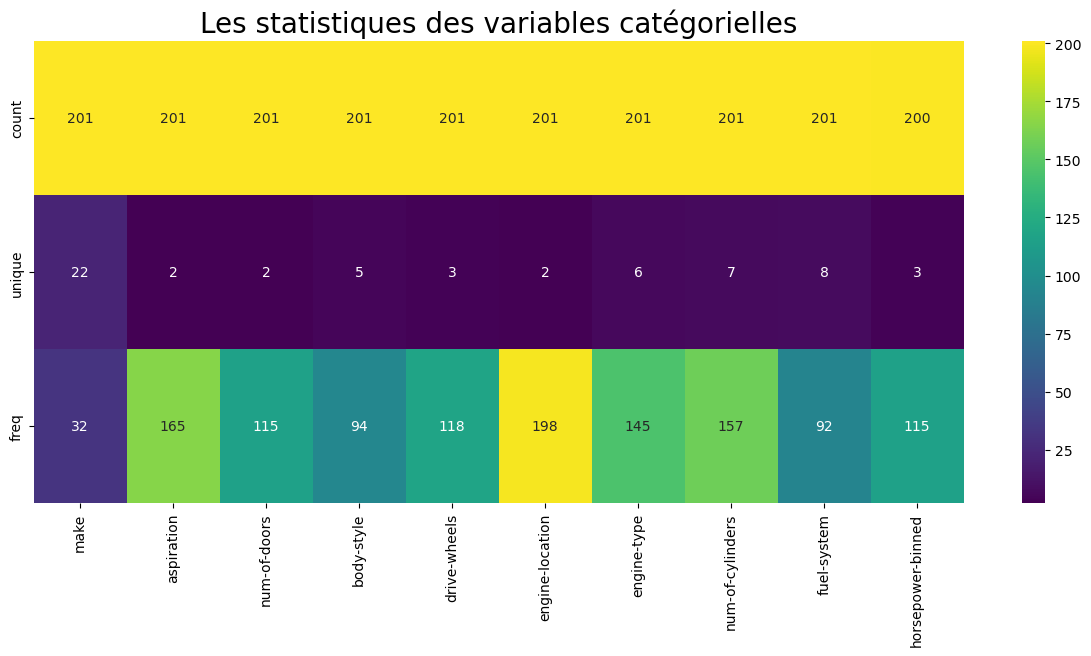

In [7]:
# VOIR LES LES STATISTIS DESCRIPTIVES DE VARIABLES CATÉGORIELLES

# 1. Extraire les valeurs 'count', 'unique' et 'freq'
freq_data = df.describe(include="object").loc[["count","unique","freq"]]
# 2. Convertires ces valeurs en une float
freq_data = freq_data.astype(float)

# LA CARTE POUR VOIR LES STATISTIQUES DES VALEURS CATÉGORIELLES
plt.figure(figsize=(15,6))
sns.heatmap(freq_data, annot=True, fmt=".0f", cmap="viridis")
plt.title("Les statistiques des variables catégorielles", fontsize=20)
plt.show()

In [8]:
# LES STATISTIQUES DES VALEURS NUMÉRIQUES
df.describe()

,Unnamed: 0,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
count,201.000000,201.000000,201.00000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,197.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,100.000000,0.840796,122.00000,98.797015,0.837102,0.915126,53.766667,2555.666667,126.875622,3.330692,3.256904,10.164279,103.405534,5117.665368,25.179104,30.686567,13207.129353,9.944145,0.099502,0.900498
std,58.167861,1.254802,31.99625,6.066366,0.059213,0.029187,2.447822,517.296727,41.546834,0.268072,0.319256,4.004965,37.365700,478.113805,6.423220,6.815150,7947.066342,2.534599,0.300083,0.300083
min,0.000000,-2.000000,65.00000,86.600000,0.678039,0.837500,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000,4.795918,0.000000,0.000000
25%,50.000000,0.000000,101.00000,94.500000,0.801538,0.890278,52.000000,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000,7.833333,0.000000,1.000000
50%,100.000000,1.000000,122.00000,97.000000,0.832292,0.909722,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5125.369458,24.000000,30.000000,10295.000000,9.791667,0.000000,1.000000
75%,150.000000,2.000000,137.00000,102.400000,0.881788,0.925000,55.500000,2926.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000,12.368421,0.000000,1.000000
max,200.000000,3.000000,256.00000,120.900000,1.000000,1.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000,18.076923,1.000000,1.000000


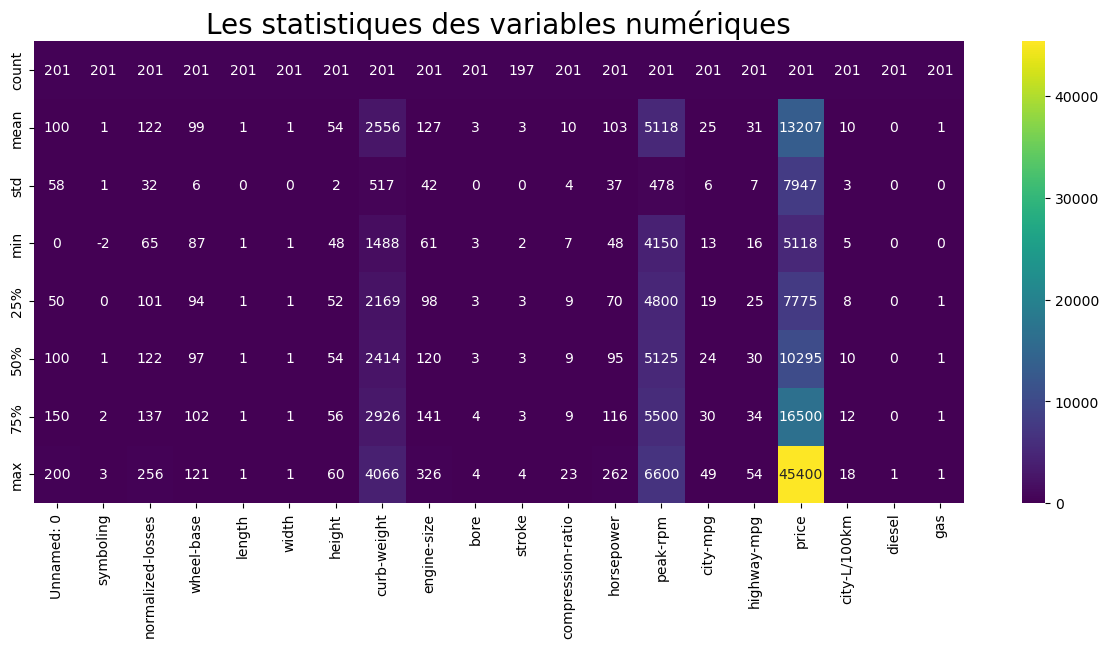

In [9]:
# LA CARTE POUR VOIR LES STATISTIQUES DES VALEURS NUMÉRIQUES
plt.figure(figsize=(15,6))
sns.heatmap(df.describe(), annot=True, fmt=".0f", cmap="viridis")
plt.title("Les statistiques des variables numériques", fontsize=20)
plt.show()

## 3. DATA CLEANING (NETTOYAGE DES DONNÉES)

In [10]:
# 1. Les valeurs dupliquées
df.duplicated().sum() # Pas des valeurs dupliquées

np.int64(0)

In [11]:
# 2. Les valeurs nulles 
df.isnull().sum().sort_values(ascending=False)

stroke               4
horsepower-binned    1
normalized-losses    0
make                 0
Unnamed: 0           0
symboling            0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
aspiration           0
num-of-doors         0
curb-weight          0
height               0
engine-size          0
engine-type          0
fuel-system          0
bore                 0
compression-ratio    0
num-of-cylinders     0
horsepower           0
peak-rpm             0
highway-mpg          0
city-mpg             0
price                0
city-L/100km         0
diesel               0
gas                  0
dtype: int64

In [12]:
# REMPLACER LA VALEUR MANQUANTE CATÉGORIELLE EN VALEUR LA PLUS FRÉQUENTE DE LA COLONNE
most_freq = df["horsepower-binned"].mode()[0]
print(f"{most_freq} les la variable la plus fréquente de notre colonne")

# Le remplacemnt 
df["horsepower-binned"] = df["horsepower-binned"].fillna(most_freq)
df["stroke"] = df["stroke"].fillna(df["stroke"].mean())


Low les la variable la plus fréquente de notre colonne


In [13]:
# REVOIR LES VALEURS NULLES DE NOTRE DATASET
df.isnull().sum()

Unnamed: 0           0
symboling            0
normalized-losses    0
make                 0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
city-L/100km         0
horsepower-binned    0
diesel               0
gas                  0
dtype: int64

In [14]:
# SUPRIMER LA COLONE 'Unnamed: 0'
df = df.drop("Unnamed: 0", axis=1)
df

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,0.890278,48.8,2548,dohc,four,130,mpfi,3.470000,2.680000,9.00,111.000000,5000.000000,21,27,13495.0,11.190476,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,0.890278,48.8,2548,dohc,four,130,mpfi,3.470000,2.680000,9.00,111.000000,5000.000000,21,27,16500.0,11.190476,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,0.909722,52.4,2823,ohcv,six,152,mpfi,2.680000,3.470000,9.00,154.000000,5000.000000,19,26,16500.0,12.368421,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,0.919444,54.3,2337,ohc,four,109,mpfi,3.190000,3.400000,10.00,102.000000,5500.000000,24,30,13950.0,9.791667,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,0.922222,54.3,2824,ohc,five,136,mpfi,3.190000,3.400000,8.00,115.000000,5500.000000,18,22,17450.0,13.055556,Medium,0,1
5,2,122,audi,std,two,sedan,fwd,front,99.8,0.851994,0.920833,53.1,2507,ohc,five,136,mpfi,3.190000,3.400000,8.50,110.000000,5500.000000,19,25,15250.0,12.368421,Medium,0,1
6,1,158,audi,std,four,sedan,fwd,front,105.8,0.925997,0.991667,55.7,2844,ohc,five,136,mpfi,3.190000,3.400000,8.50,110.000000,5500.000000,19,25,17710.0,12.368421,Medium,0,1
7,1,122,audi,std,four,wagon,fwd,front,105.8,0.925997,0.991667,55.7,2954,ohc,five,136,mpfi,3.190000,3.400000,8.50,110.000000,5500.000000,19,25,18920.0,12.368421,Medium,0,1
8,1,158,audi,turbo,four,sedan,fwd,front,105.8,0.925997,0.991667,55.9,3086,ohc,five,131,mpfi,3.130000,3.400000,8.30,140.000000,5500.000000,17,20,23875.0,13.823529,Medium,0,1
9,2,192,bmw,std,two,sedan,rwd,front,101.2,0.849592,0.900000,54.3,2395,ohc,four,108,mpfi,3.500000,2.800000,8.80,101.000000,5800.000000,23,29,16430.0,10.217391,Low,0,1


## 3. EXPLORASITORY DATA ANALYSIS (ANALYSE EXPLORATOIR DES DONNÉES)

#### 3.1 ANALYSE UNIVARIÉE DES VARIBLES NUMÉRIQUES

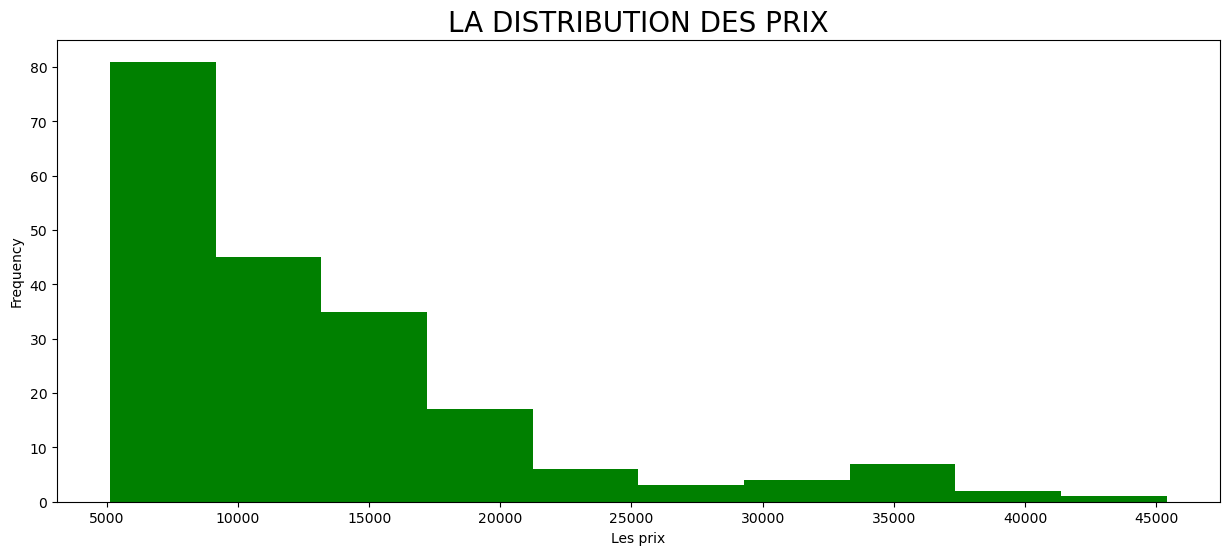

In [15]:
# HISTOGRAMME DES PRIX
plt.figure(figsize=(15,6))
df["price"].plot(kind="hist", color="green")
plt.title("LA DISTRIBUTION DES PRIX", fontsize=20)
plt.xlabel("Les prix")
plt.show()

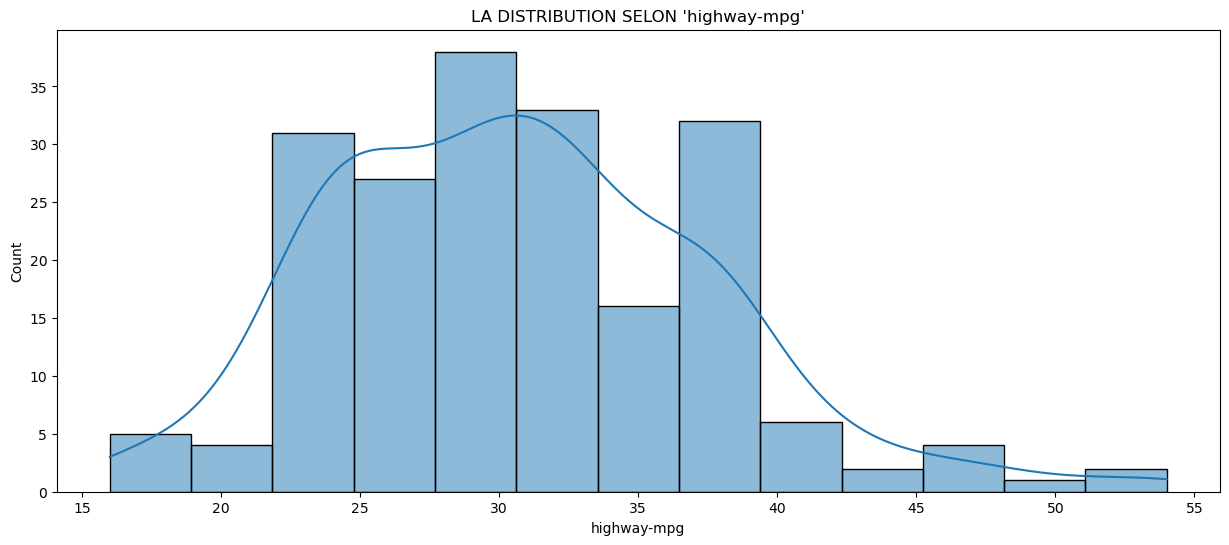

In [16]:
# ANALYSE DE "highway-mpg"
plt.figure(figsize=(15,6))
sns.histplot(df["highway-mpg"], kde=True)
plt.title("LA DISTRIBUTION SELON 'highway-mpg'")
plt.show()

Text(0, 0.5, 'price')

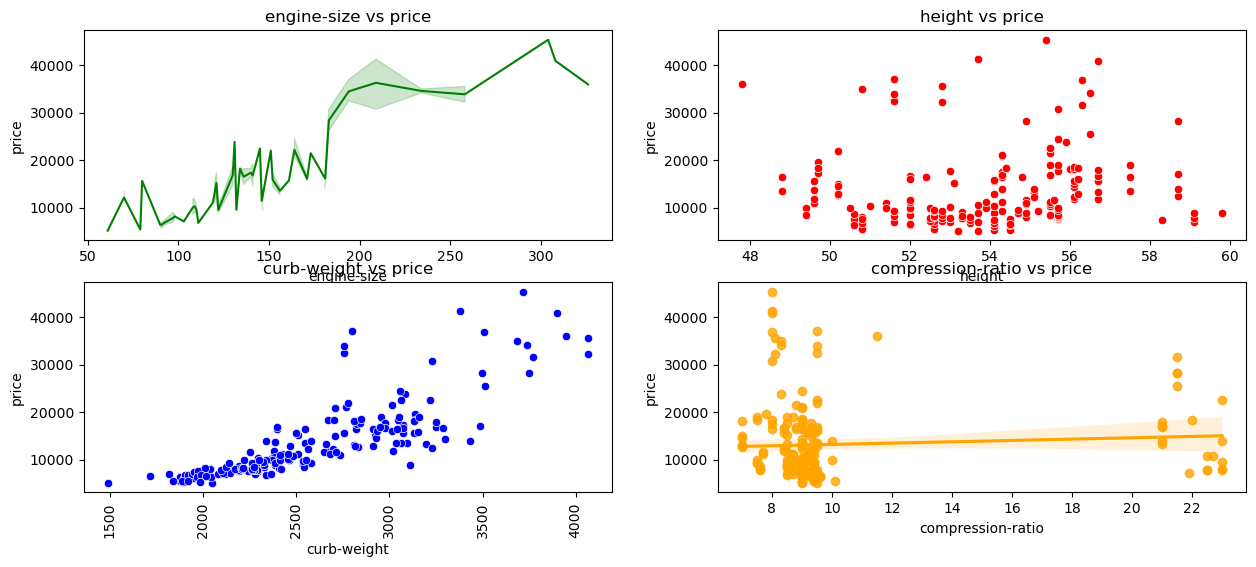

In [17]:
# SUBPLOT DES VARIABLES 'engine-size','height','curb-weight' ET 'compression-ratio'
fig, axes = plt.subplots(2, 2, figsize=(15,6))

# Graphe 1
sns.lineplot(data=df, x="engine-size", y="price", color="green", ax=axes[0,0])
axes[0,0].set_title("engine-size vs price")
axes[0,0].set_ylabel("price")


# Graphe 2
sns.scatterplot(data=df, x="height", y="price", color="red", ax=axes[0,1])
axes[0,1].set_title("height vs price")
axes[0,1].set_ylabel("price")


# Graphe 3 
sns.scatterplot(data=df, x="curb-weight", y="price", color="blue", ax=axes[1,0])
axes[1,0].set_title("curb-weight vs price")
axes[1,0].set_ylabel("price")
axes[1,0].tick_params("x", rotation=90)


# Graphe 4
sns.regplot(data=df, x="compression-ratio", y="price", color="orange", ax=axes[1,1])
axes[1,1].set_title("compression-ratio vs price")
axes[1,1].set_ylabel("price")


#### 3.2 ANALYSE UNIVARIÉE DES VARIBLES CATÉGORIELLES

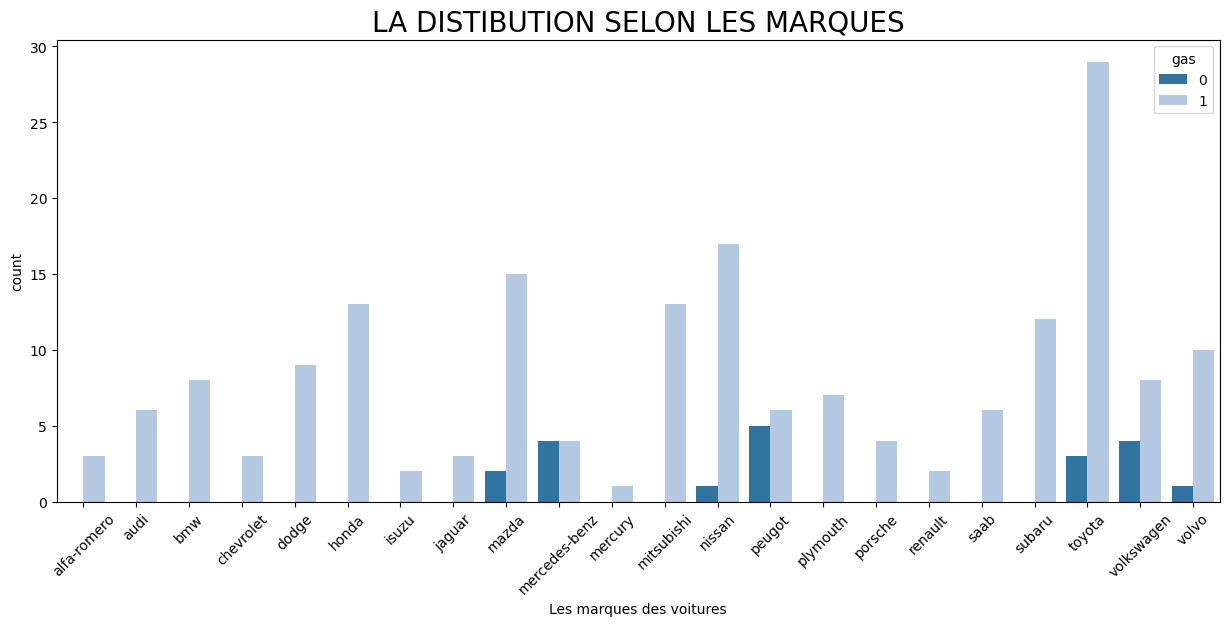

In [18]:
# ANALYSE UNIVARIÉES DES MARQUES
plt.figure(figsize=(15,6))
sns.countplot(data=df, x="make",hue="gas", palette="tab20")
plt.title("LA DISTIBUTION SELON LES MARQUES", fontsize=20)
plt.xticks(rotation=45)
plt.xlabel("Les marques des voitures")
plt.show()

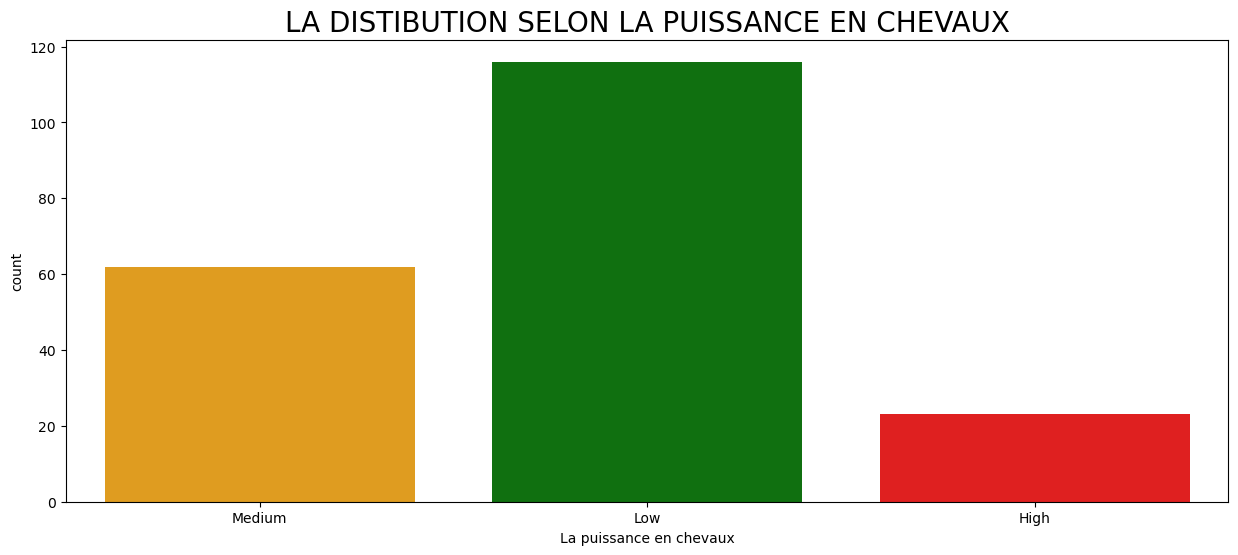

In [19]:
# LA DISTRIBUTION DE 'horsepower-binned'
plt.figure(figsize=(15,6))
sns.countplot(data=df, x="horsepower-binned",hue="horsepower-binned", palette=["orange", "green", "red"])
plt.title("LA DISTIBUTION SELON LA PUISSANCE EN CHEVAUX", fontsize=20)
plt.xlabel("La puissance en chevaux")
plt.show()

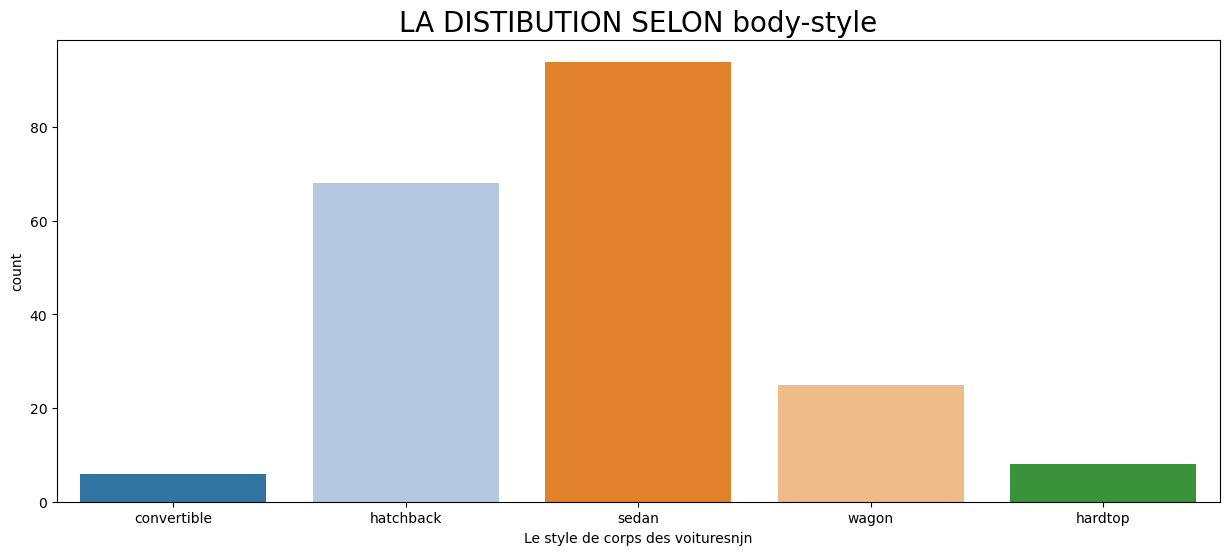

In [20]:
# LA DISTRIBUTION DE 'body-style'
plt.figure(figsize=(15,6))
sns.countplot(data=df, x="body-style",hue="body-style", palette="tab20")
plt.title("LA DISTIBUTION SELON body-style", fontsize=20)
plt.xlabel("Le style de corps des voituresnjn")
plt.show()

In [21]:
# VOIR LES VALEURS CATÉGORIELLES
df_cat = df.select_dtypes("object")
df_cat

,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system,horsepower-binned
0,alfa-romero,std,two,convertible,rwd,front,dohc,four,mpfi,Medium
1,alfa-romero,std,two,convertible,rwd,front,dohc,four,mpfi,Medium
2,alfa-romero,std,two,hatchback,rwd,front,ohcv,six,mpfi,Medium
3,audi,std,four,sedan,fwd,front,ohc,four,mpfi,Medium
4,audi,std,four,sedan,4wd,front,ohc,five,mpfi,Medium
5,audi,std,two,sedan,fwd,front,ohc,five,mpfi,Medium
6,audi,std,four,sedan,fwd,front,ohc,five,mpfi,Medium
7,audi,std,four,wagon,fwd,front,ohc,five,mpfi,Medium
8,audi,turbo,four,sedan,fwd,front,ohc,five,mpfi,Medium
9,bmw,std,two,sedan,rwd,front,ohc,four,mpfi,Low


Text(0, 0.5, 'compression-ratio')

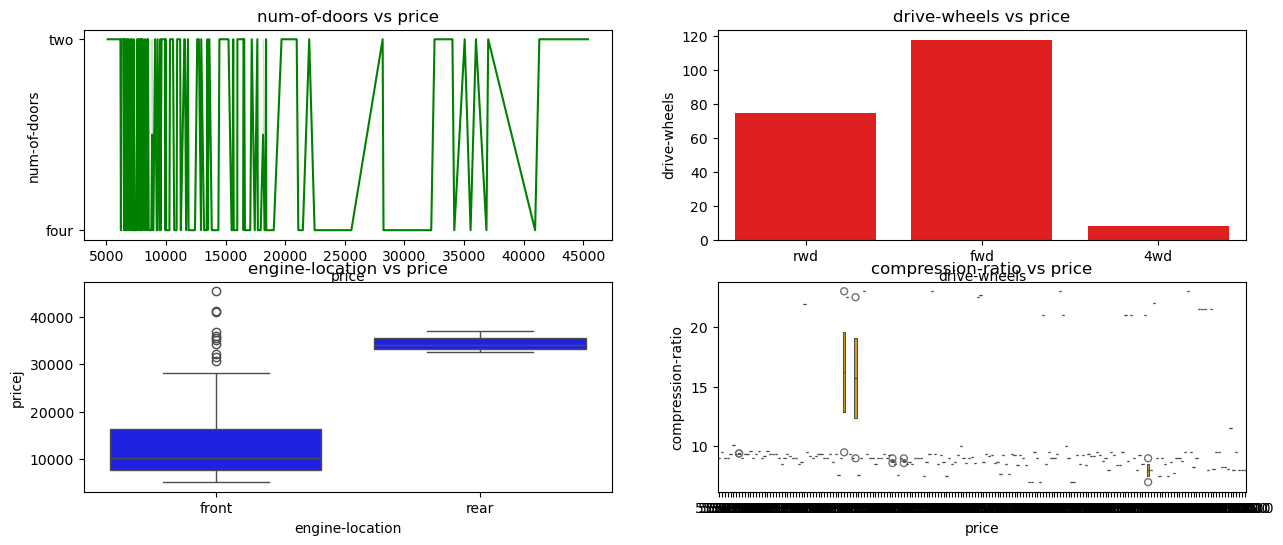

In [22]:
# SUBPLOT DES VARIABLES 'num-of-doors','drive-wheels','engine-location'ET 'fuel-system'
fig, axes = plt.subplots(2, 2, figsize=(15,6))

# Graphe 1
sns.lineplot(data=df, x="price", y="num-of-doors", color="green", ax=axes[0,0])
axes[0,0].set_title("num-of-doors vs price")
axes[0,0].set_ylabel("num-of-doors")


# Graphe 2
sns.countplot(data=df, x="drive-wheels", color="red", ax=axes[0,1])
axes[0,1].set_title("drive-wheels vs price")
axes[0,1].set_ylabel("drive-wheels")



sns.boxplot(data=df, x="engine-location", y="price", color="blue", ax=axes[1,0])
axes[1,0].set_title("engine-location vs price")
axes[1,0].set_ylabel("pricej")


# Graphe 4
sns.boxenplot(data=df, x="price", y="compression-ratio", color="orange", ax=axes[1,1])
axes[1,1].set_title("compression-ratio vs price")
axes[1,1].set_ylabel("compression-ratio")


In [23]:
# VOIR LES DONNÉES NUMÉRIQUES
df_num = df.select_dtypes("number")
df_num

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
0,3,122,88.6,0.811148,0.890278,48.8,2548,130,3.470000,2.680000,9.00,111.000000,5000.000000,21,27,13495.0,11.190476,0,1
1,3,122,88.6,0.811148,0.890278,48.8,2548,130,3.470000,2.680000,9.00,111.000000,5000.000000,21,27,16500.0,11.190476,0,1
2,1,122,94.5,0.822681,0.909722,52.4,2823,152,2.680000,3.470000,9.00,154.000000,5000.000000,19,26,16500.0,12.368421,0,1
3,2,164,99.8,0.848630,0.919444,54.3,2337,109,3.190000,3.400000,10.00,102.000000,5500.000000,24,30,13950.0,9.791667,0,1
4,2,164,99.4,0.848630,0.922222,54.3,2824,136,3.190000,3.400000,8.00,115.000000,5500.000000,18,22,17450.0,13.055556,0,1
5,2,122,99.8,0.851994,0.920833,53.1,2507,136,3.190000,3.400000,8.50,110.000000,5500.000000,19,25,15250.0,12.368421,0,1
6,1,158,105.8,0.925997,0.991667,55.7,2844,136,3.190000,3.400000,8.50,110.000000,5500.000000,19,25,17710.0,12.368421,0,1
7,1,122,105.8,0.925997,0.991667,55.7,2954,136,3.190000,3.400000,8.50,110.000000,5500.000000,19,25,18920.0,12.368421,0,1
8,1,158,105.8,0.925997,0.991667,55.9,3086,131,3.130000,3.400000,8.30,140.000000,5500.000000,17,20,23875.0,13.823529,0,1
9,2,192,101.2,0.849592,0.900000,54.3,2395,108,3.500000,2.800000,8.80,101.000000,5800.000000,23,29,16430.0,10.217391,0,1


In [24]:
# LA CORRÉLATION DES VARIABLES NUMÉRIQUES
df_num.corr()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
symboling,1.000000,0.466264,-0.535987,-0.365404,-0.242423,-0.550160,-0.233118,-0.110581,-0.140019,-0.007992,-0.182196,0.075819,0.279740,-0.035527,0.036233,-0.082391,0.066171,-0.196735,0.196735
normalized-losses,0.466264,1.000000,-0.056661,0.019424,0.086802,-0.373737,0.099404,0.112360,-0.029862,0.055127,-0.114713,0.217299,0.239543,-0.225016,-0.181877,0.133999,0.238567,-0.101546,0.101546
wheel-base,-0.535987,-0.056661,1.000000,0.876024,0.814507,0.590742,0.782097,0.572027,0.493244,0.157964,0.250313,0.371147,-0.360305,-0.470606,-0.543304,0.584642,0.476153,0.307237,-0.307237
length,-0.365404,0.019424,0.876024,1.000000,0.857170,0.492063,0.880665,0.685025,0.608971,0.123913,0.159733,0.579821,-0.285970,-0.665192,-0.698142,0.690628,0.657373,0.211187,-0.211187
width,-0.242423,0.086802,0.814507,0.857170,1.000000,0.306002,0.866201,0.729436,0.544885,0.188814,0.189867,0.615077,-0.245800,-0.633531,-0.680635,0.751265,0.673363,0.244356,-0.244356
height,-0.550160,-0.373737,0.590742,0.492063,0.306002,1.000000,0.307581,0.074694,0.180449,-0.060822,0.259737,-0.087027,-0.309974,-0.049800,-0.104812,0.135486,0.003811,0.281578,-0.281578
curb-weight,-0.233118,0.099404,0.782097,0.880665,0.866201,0.307581,1.000000,0.849072,0.644060,0.167412,0.156433,0.757976,-0.279361,-0.749543,-0.794889,0.834415,0.785353,0.221046,-0.221046
engine-size,-0.110581,0.112360,0.572027,0.685025,0.729436,0.074694,0.849072,1.000000,0.572609,0.205806,0.028889,0.822676,-0.256733,-0.650546,-0.679571,0.872335,0.745059,0.070779,-0.070779
bore,-0.140019,-0.029862,0.493244,0.608971,0.544885,0.180449,0.644060,0.572609,1.000000,-0.055390,0.001263,0.566936,-0.267392,-0.582027,-0.591309,0.543155,0.554610,0.054458,-0.054458
stroke,-0.007992,0.055127,0.157964,0.123913,0.188814,-0.060822,0.167412,0.205806,-0.055390,1.000000,0.187854,0.098282,-0.063388,-0.034079,-0.034741,0.082267,0.036285,0.241033,-0.241033


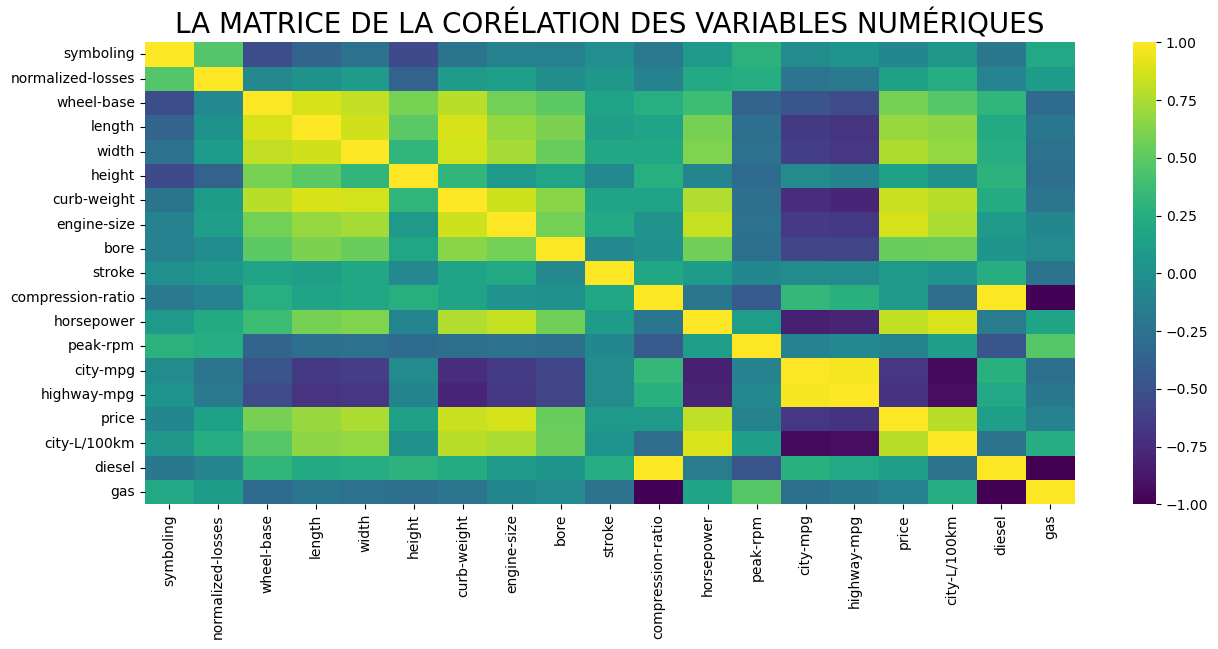

In [25]:
# UNE CARTE MONTRE LA CORÉLATION DES VARIABLES
plt.figure(figsize=(15,6))
sns.heatmap(data=df_num.corr(), cmap="viridis")
plt.title("LA MATRICE DE LA CORÉLATION DES VARIABLES NUMÉRIQUES", fontsize=20)
plt.show()

#### *LES TESTES STATISTIQUES POUR VOIRE LA CORRÉLATION DES VARIABLES*

In [29]:
# 1. TEST DE STUDENT

# VOIRS LES VALEURS UNIQUES DE LA VARIABLE "aspiration"
df["aspiration"].value_counts()

# GROUPER LES VARIBALES CATÉGORIELLES (aspiration) EN FONCTION DES PRIX
group1 = df[df["aspiration"] == "std"]["price"]
group2 = df[df["aspiration"] == "turbo"]["price"]

# TEST
stat, p_value = f_oneway(group1,group2)

# INTERPRETATION
if p_value < 0.05:
    print(f"{p_value:.2f} < 0.05: Il y'a une corrélation significative entre les variable aspiration et les prix des voitures")
else:
    print(f"{p_value:.2f} >= 0.05: Il n' y'a pas corrélation entre les variable aspiration et les prix des voitures")

0.01 < 0.05: Il y'a une corrélation significative entre les variable aspiration et les prix des voitures
